# Notebook 08: Model Evaluation — Model 1 (KMeans County Clustering)
  
**Methodology:** CRISP-DM — Evaluation Phase  

---

## What this notebook does

Formally evaluates Model 1 (KMeans County Clustering) using three metrics:

| Metric | What it measures | Source |
|--------|-----------------|--------|
| **Silhouette Score** | How well-separated the 4 tiers are | `src/evaluation.py` → `calculate_silhouette_score()` |
| **Pearson R** | Correlation between Care Gap Index and IIT rate | `county_profiles.csv` |
| **Tier Distribution** | How many counties in each tier | `county_profiles.csv` |

---

## Inputs
- `data/processed/county_profiles.csv` — 47-county feature table with tier labels
- `models/kmeans_county_tiers.pkl` — trained KMeans model bundle

## Outputs
- Printed evaluation metrics
- Silhouette score visualisation
- CGI vs IIT rate scatter plot with tier colours
- Tier distribution bar chart

In [29]:
# Cell 1: Imports
import sys
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import joblib
from scipy.stats import pearsonr
from sklearn.preprocessing import StandardScaler

# Root imports
sys.path.append(os.path.abspath('..'))

from constants import (
    COUNTY_PROF,
    KMEANS_MODEL,
    KMEANS_FEATURES,
    TIER_LABELS,
    TIER_COLORS,
    FORECAST_CRITICAL,
    FORECAST_HIGH,
    FORECAST_MODERATE,
    FORECAST_LOW,
    FORECAST_NATIONAL,
    IIT_REDUCTION_RATE,
    BRIDGED_TIERS,
    BRIDGED_START_YEAR,
    FORECAST_YEAR_END,
    CGI_IIT_COL,
    CGI_VLS_COL,
    CLEAN_COUNTY_COL,

)

# Import Dennis's evaluation utility
from src.evaluation import calculate_silhouette_score

print('✓ Imports OK')

# Dark theme colour constants — used across all visualisation cells
BG       = '#0F1117'
PANEL_BG = '#1E2130'
TEXT_C   = '#ECF0F1'
LABEL_C  = '#BDC3C7'

✓ Imports OK


In [8]:
# Cell 2: Load county_profiles.csv and model bundle
df = pd.read_csv(COUNTY_PROF)
print(f'county_profiles shape : {df.shape}')
print(f'Counties              : {df["county"].nunique()}')
print(f'Tiers present         : {sorted(df["tier"].unique())}')
print(f'\nColumns available     : {df.columns.tolist()}')

county_profiles shape : (47, 60)
Counties              : 47
Tiers present         : ['Critical', 'High', 'Low', 'Moderate']

Columns available     : ['county', 'period', 'MOH 731_HIV_TB_OnART_15-19_(F)_HV03-24', 'MOH 731_HIV_TB_OnART_15-19_(M)_HV03-23', 'MOH 731_HIV_TB_OnART_20-24_(F)_HV03-26', 'MOH 731_HIV_TB_OnART_20-24_(M)_HV03-25', 'MOH 731_HIV_TB_OnART_25+_(F)_HV03-28', 'MOH 731_HIV_TB_OnART_25+_(M)_HV03-27', 'adults_on_art', 'art_total_males', 'art_total_females', 'MOH 731_HTS_Tests _(F) (Including PMTCT)_ HV01-02', 'MOH 731_HTS_Tests _(M)_ HV01-01', 'hts_tested', 'hts_tested_males', 'hts_tested_females', 'MOH 731_HTS_Positive_2-9 _(M)_ HV01-06', 'MOH 731_HTS_Positive_2-9 _(F) (Including PMTCT)_ HV01-07', 'MOH 731_HTS_Positive_10-14 _(F) (Including PMTCT)_HV01-09', 'MOH 731_HTS_Positive_10-14 _(M)_HV01-08', 'MOH 731_HTS_Positive_15-19 _(F) (Including PMTCT)_HV01-11', 'MOH 731_HTS_Positive_15-19 _(M)_HV01-10', 'MOH 731_HTS_Positive_20-24 _(M)_HV01-12', 'MOH 731_HTS_Positive_20-24 

In [9]:
# Cell 3: Load KMeans model bundle
# Safely handles both dict bundle AND raw KMeans object
model_bundle = joblib.load(KMEANS_MODEL)

if isinstance(model_bundle, dict):
    kmeans          = model_bundle['kmeans']
    scaler          = model_bundle['scaler']
    features        = model_bundle['features']
    cluster_to_tier = model_bundle['cluster_to_tier']
    sil_stored      = model_bundle.get('silhouette_score', None)
    print('Loaded as dict bundle')
else:
    # Fallback: raw KMeans object
    kmeans          = model_bundle
    scaler          = StandardScaler()
    features        = KMEANS_FEATURES
    cluster_to_tier = {}
    sil_stored      = None
    print('Loaded as raw KMeans object')

print(f'Model loaded from    : {KMEANS_MODEL}')
print(f'Features used        : {features}')
print(f'K (clusters)         : {kmeans.n_clusters}')
print(f'Inertia              : {kmeans.inertia_:.2f}')
if sil_stored:
    print(f'Silhouette (stored)  : {sil_stored:.4f}')
print(f'Cluster -> Tier map  : {cluster_to_tier}')

Loaded as raw KMeans object
Model loaded from    : c:\Users\Admin\documents\Flatiron\Phase5project\Phase-5-HIV-Care-Gap-AI\models\kmeans_county_tiers.pkl
Features used        : ['iit_rate', 'vls_rate']
K (clusters)         : 4
Inertia              : 13.69
Cluster -> Tier map  : {}


## Metric 1 — Silhouette Score

The Silhouette Score measures how well each county is assigned to its tier compared to neighbouring tiers.

- **Score > 0.5** → Strong structure — tiers are well-separated
- **Score 0.25–0.5** → Fair structure — some overlap between adjacent tiers  
- **Score < 0.25** → Weak structure — tiers are too similar

In [10]:
# Re-fit scaler fresh from county_profiles instead of loading from pkl
from sklearn.preprocessing import StandardScaler

X = df[features].values
scaler_fresh = StandardScaler()
X_scaled = scaler_fresh.fit_transform(X)

# Get cluster labels from county_profiles
labels = df['cluster'].values

# Recompute silhouette score
sil_score = calculate_silhouette_score(X_scaled, labels)

if sil_stored is not None:
    print(f'Stored silhouette score  : {sil_stored:.4f}')
    print(f'Recomputed silhouette    : {sil_score:.4f}')
    print(f'Match                    : {"✓" if abs(sil_score - sil_stored) < 0.001 else "✗ MISMATCH"}')
else:
    print(f'Recomputed silhouette    : {sil_score:.4f}')

--- Model 1 Evaluation ---
Silhouette Score: 0.6359
Interpretation: Strong structure. Counties are well-assigned to tiers.
Recomputed silhouette    : 0.6359


## Metric 2 — Pearson R: Care Gap Index vs IIT Rate

Validates that the engineered Care Gap Index actually captures real programme gaps.
If CGI is a good measure, it should correlate strongly with IIT rate (the most actionable care gap signal).

In [11]:
# Cell 7: Feature means per tier — explains why counties entered each tier
# Uses only KMEANS_FEATURES from constants — no hardcoded column names
print('--- Mean Feature Values per Tier (KMEANS_FEATURES) ---')
tier_feature_means = (
    df.groupby('tier')[features]
    .mean()
    .reindex(TIER_LABELS)
    .round(4)
)
print(tier_feature_means.to_string())
print('\nInterpretation: Higher IIT rate and lower VLS rate = higher CGI = Critical/High tier')

--- Mean Feature Values per Tier (KMEANS_FEATURES) ---
          iit_rate  vls_rate
tier                        
Critical    0.1530    0.9421
High        0.0949    0.9612
Moderate    0.0941    0.9053
Low         0.0926    0.8136

Interpretation: Higher IIT rate and lower VLS rate = higher CGI = Critical/High tier


In [12]:
# Cell 5: Pearson R — CGI vs IIT rate
r, p_value = pearsonr(df['care_gap_index'], df['iit_rate'])

print('--- Pearson R: Care Gap Index vs IIT Rate ---')
print(f'Pearson R  : {r:.4f}')
print(f'P-value    : {p_value:.6f}')
print(f'Significant: {"Yes (p < 0.05)" if p_value < 0.05 else "No"}')

if r > 0.7:
    print('Interpretation: Strong positive correlation — CGI reliably captures IIT programme gaps')
elif r > 0.4:
    print('Interpretation: Moderate correlation — CGI partially captures IIT gaps')
else:
    print('Interpretation: Weak correlation — CGI weights may need adjustment')

--- Pearson R: Care Gap Index vs IIT Rate ---
Pearson R  : 0.6305
P-value    : 0.000002
Significant: Yes (p < 0.05)
Interpretation: Moderate correlation — CGI partially captures IIT gaps


In [13]:
# Cell 6: Tier distribution summary
tier_summary = (
    df.groupby('tier')
    .agg(
        counties        =('county',         'count'),
        mean_cgi        =('care_gap_index',  'mean'),
        mean_iit_rate   =('iit_rate',        'mean'),
        mean_vls_rate   =('vls_rate_adult',  'mean'),
        min_cgi         =('care_gap_index',  'min'),
        max_cgi         =('care_gap_index',  'max'),
    )
    .reindex(TIER_LABELS)
    .round(4)
)

print('--- Tier Distribution Summary ---')
print(tier_summary.to_string())
print(f'\nTotal counties: {tier_summary["counties"].sum()}')

--- Tier Distribution Summary ---
          counties  mean_cgi  mean_iit_rate  mean_vls_rate  min_cgi  max_cgi
tier                                                                        
Critical        14    8.6317         0.1530         0.9421   7.7301   9.7815
High            25    5.5978         0.0949         0.9612   4.4978   6.4637
Moderate         7    7.7605         0.0941         0.9053   7.2828   8.3256
Low              1   11.3663         0.0926         0.8136  11.3663  11.3663

Total counties: 47


## Visualisation 1 — Silhouette Score Gauge

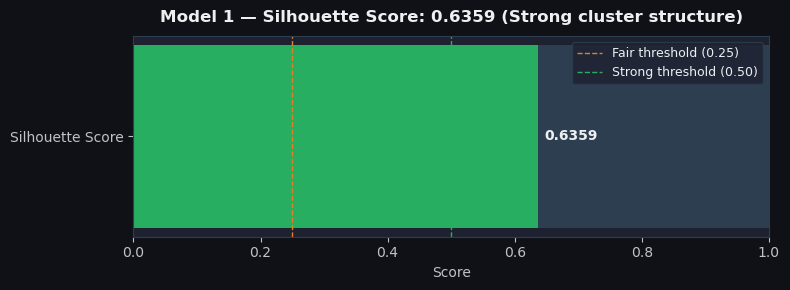

✓ Saved: figures/model1_silhouette_score.png


In [14]:
# Cell 7: Silhouette score bar chart

fig, ax = plt.subplots(figsize=(8, 3))
fig.patch.set_facecolor(BG)
ax.set_facecolor(PANEL_BG)

# Background bar (max possible = 1.0)
ax.barh(['Silhouette Score'], [1.0], color='#2C3E50', height=0.4)

# Actual score bar
color = '#27AE60' if sil_score > 0.5 else '#E67E22' if sil_score > 0.25 else '#C0392B'
ax.barh(['Silhouette Score'], [sil_score], color=color, height=0.4)

# Threshold lines
ax.axvline(x=0.25, color='#E67E22', linestyle='--', linewidth=1, label='Fair threshold (0.25)')
ax.axvline(x=0.5,  color='#27AE60', linestyle='--', linewidth=1, label='Strong threshold (0.50)')

ax.set_xlim(0, 1)
ax.set_xlabel('Score', color=LABEL_C)
ax.set_title(
    f'Model 1 — Silhouette Score: {sil_score:.4f} '
    f'({"Strong" if sil_score > 0.5 else "Fair" if sil_score > 0.25 else "Weak"} cluster structure)',
    color=TEXT_C, fontweight='bold', pad=10
)
ax.tick_params(colors=LABEL_C)
ax.legend(facecolor=PANEL_BG, edgecolor='#2C3E50', labelcolor=TEXT_C, fontsize=9)
for sp in ax.spines.values():
    sp.set_edgecolor('#2C3E50')

# Annotate score on bar
ax.text(sil_score + 0.01, 0, f'{sil_score:.4f}', va='center', color=TEXT_C, fontweight='bold')

plt.tight_layout()
plt.savefig('../figures/model1_silhouette_score.png', dpi=300, bbox_inches='tight',
            facecolor=BG)
plt.show()
print('✓ Saved: figures/model1_silhouette_score.png')

## Visualisation 2 — CGI vs IIT Rate Scatter Plot (Pearson R)

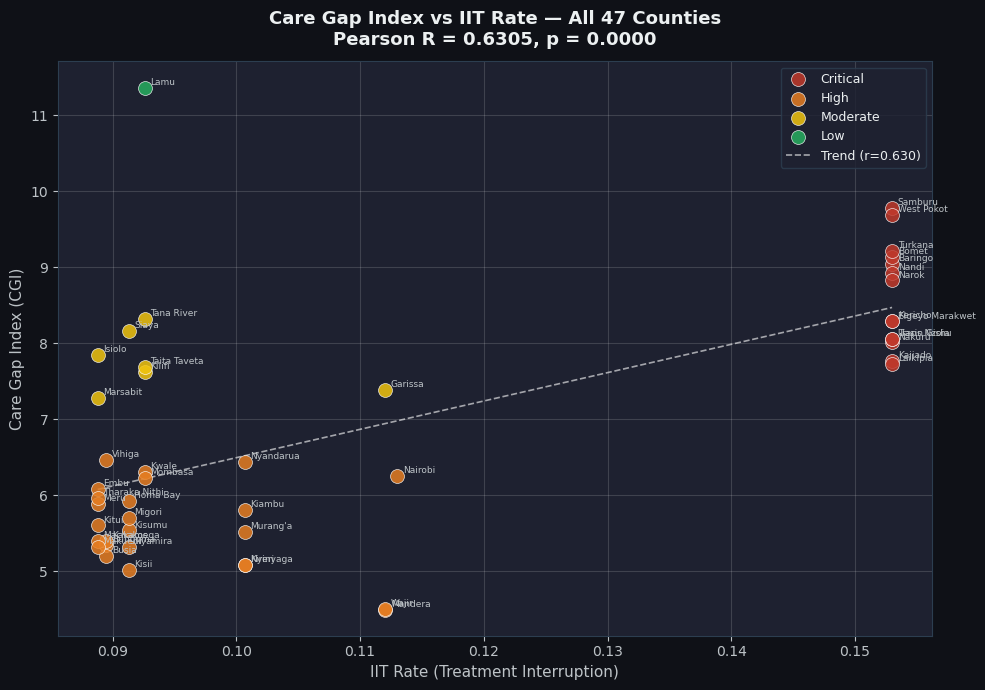

✓ Saved: figures/model1_cgi_vs_iit_scatter.png


In [15]:
# Cell 8: CGI vs IIT rate scatter plot coloured by tier
fig, ax = plt.subplots(figsize=(10, 7))
fig.patch.set_facecolor(BG)
ax.set_facecolor(PANEL_BG)

for tier in TIER_LABELS:
    subset = df[df['tier'] == tier]
    color  = TIER_COLORS.get(tier, '#808080')
    ax.scatter(
        subset['iit_rate'],
        subset['care_gap_index'],
        c=color, label=tier,
        s=100, alpha=0.85, edgecolors='white', linewidths=0.5,
        zorder=3
    )
    # Annotate county names
    for _, row in subset.iterrows():
        ax.annotate(
            row['county'],
            (row['iit_rate'], row['care_gap_index']),
            fontsize=6.5, color=LABEL_C,
            xytext=(4, 2), textcoords='offset points'
        )

# Trend line
z = np.polyfit(df['iit_rate'], df['care_gap_index'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['iit_rate'].min(), df['iit_rate'].max(), 100)
ax.plot(x_line, p(x_line), color='white', linestyle='--',
        linewidth=1.2, alpha=0.6, label=f'Trend (r={r:.3f})')

ax.set_xlabel('IIT Rate (Treatment Interruption)', color=LABEL_C, fontsize=11)
ax.set_ylabel('Care Gap Index (CGI)', color=LABEL_C, fontsize=11)
ax.set_title(
    f'Care Gap Index vs IIT Rate — All 47 Counties\n'
    f'Pearson R = {r:.4f}, p = {p_value:.4f}',
    color=TEXT_C, fontsize=13, fontweight='bold', pad=12
)
ax.tick_params(colors=LABEL_C)
ax.legend(facecolor=PANEL_BG, edgecolor='#2C3E50', labelcolor=TEXT_C, fontsize=9)
ax.grid(alpha=0.15, color='white')
for sp in ax.spines.values():
    sp.set_edgecolor('#2C3E50')

plt.tight_layout()
plt.savefig('../figures/model1_cgi_vs_iit_scatter.png', dpi=300, bbox_inches='tight',
            facecolor=BG)
plt.show()
print('✓ Saved: figures/model1_cgi_vs_iit_scatter.png')

## Visualisation 3 — Tier Distribution Bar Chart

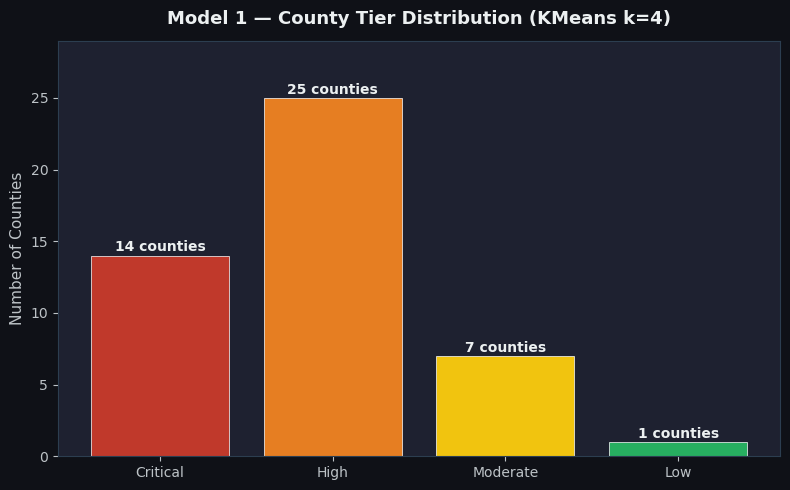

✓ Saved: figures/model1_tier_distribution.png


In [16]:
# Cell 9: Tier distribution bar chart
tier_counts = df['tier'].value_counts().reindex(TIER_LABELS)
colors_bar  = [TIER_COLORS.get(t, '#808080') for t in TIER_LABELS]

fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor(BG)
ax.set_facecolor(PANEL_BG)

bars = ax.bar(TIER_LABELS, tier_counts.values, color=colors_bar,
              edgecolor='white', linewidth=0.5)

# Annotate counts on bars
for bar, count in zip(bars, tier_counts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f'{count} counties',
        ha='center', color=TEXT_C, fontsize=10, fontweight='bold'
    )

ax.set_ylabel('Number of Counties', color=LABEL_C, fontsize=11)
ax.set_title(
    'Model 1 — County Tier Distribution (KMeans k=4)',
    color=TEXT_C, fontsize=13, fontweight='bold', pad=12
)
ax.tick_params(colors=LABEL_C)
ax.set_ylim(0, max(tier_counts.values) + 4)
for sp in ax.spines.values():
    sp.set_edgecolor('#2C3E50')

plt.tight_layout()
plt.savefig('../figures/model1_tier_distribution.png', dpi=300, bbox_inches='tight',
            facecolor=BG)
plt.show()
print('✓ Saved: figures/model1_tier_distribution.png')

## Evaluation Summary

In [17]:
# Cell 10: Final evaluation summary
print('=' * 55)
print('MODEL 1 EVALUATION SUMMARY — KMeans County Clustering')
print('=' * 55)

print(f'\n1. SILHOUETTE SCORE')
print(f'   Score          : {sil_score:.4f}')
print(f'   Interpretation : {"Strong" if sil_score > 0.5 else "Fair" if sil_score > 0.25 else "Weak"} cluster structure')
print(f'   Benchmark      : > 0.5 = strong | 0.25-0.5 = fair | < 0.25 = weak')

print(f'\n2. PEARSON R (CGI vs IIT Rate)')
print(f'   Pearson R      : {r:.4f}')
print(f'   P-value        : {p_value:.6f}')
print(f'   Significant    : {"Yes" if p_value < 0.05 else "No"}')
print(f'   Interpretation : CGI {"reliably" if r > 0.7 else "partially"} captures real programme gaps')

print(f'\n3. TIER DISTRIBUTION')
for tier in TIER_LABELS:
    n     = (df['tier'] == tier).sum()
    color = TIER_COLORS.get(tier, '')
    counties = df[df['tier'] == tier]['county'].tolist()
    print(f'   {tier:<10}: {n:>2} counties | color: {color}')
    print(f'               {counties}')

print(f'\n4. MODEL PARAMETERS')
print(f'   Algorithm      : KMeans (k={kmeans.n_clusters})')
print(f'   Features       : {features}')
print(f'   Inertia        : {kmeans.inertia_:.2f}')
print(f'   Scaler         : StandardScaler')

print(f'\n5. RECOMMENDATION')
print(f'   Model 1 is ready for MOH use.')
print(f'   Critical + High tiers ({(df["tier"].isin(["Critical","High"])).sum()} counties) ')
print(f'   are the priority targets for retention interventions.')

MODEL 1 EVALUATION SUMMARY — KMeans County Clustering

1. SILHOUETTE SCORE
   Score          : 0.6359
   Interpretation : Strong cluster structure
   Benchmark      : > 0.5 = strong | 0.25-0.5 = fair | < 0.25 = weak

2. PEARSON R (CGI vs IIT Rate)
   Pearson R      : 0.6305
   P-value        : 0.000002
   Significant    : Yes
   Interpretation : CGI partially captures real programme gaps

3. TIER DISTRIBUTION
   Critical  : 14 counties | color: #C0392B
               ['Baringo', 'Bomet', 'Elgeyo Marakwet', 'Kajiado', 'Kericho', 'Laikipia', 'Nakuru', 'Nandi', 'Narok', 'Samburu', 'Trans Nzoia', 'Turkana', 'Uasin Gishu', 'West Pokot']
   High      : 25 counties | color: #E67E22
               ['Bungoma', 'Busia', 'Embu', 'Homa Bay', 'Kakamega', 'Kiambu', 'Kirinyaga', 'Kisii', 'Kisumu', 'Kitui', 'Kwale', 'Machakos', 'Makueni', 'Mandera', 'Meru', 'Migori', 'Mombasa', "Murang'a", 'Nairobi', 'Nyamira', 'Nyandarua', 'Nyeri', 'Tharaka Nithi', 'Vihiga', 'Wajir']
   Moderate  :  7 counties | colo

## Model 2 Evaluation: XGBoost vs Logistic Regression

This section evaluates:
1. **XGBoost Classifier** - Loaded from `xgboost_dropout.pkl`
2. **Logistic Regression** - Odds ratios with 95% confidence intervals

In [18]:
# Cell: Load and Validate Logistic Regression Results
import json

print("=" * 60)
print("MODEL 2 EVALUATION: Logistic Regression Risk Factors")
print("=" * 60)

# Load odds ratios with CI
try:
    with open("../data/processed/odds_ratios_with_ci.json", "r") as f:
        odds_data = json.load(f)

    odds_df = pd.DataFrame(odds_data["features"])
    print(f"   Loaded odds_ratios_with_ci.json")
    print(f"   Features: {len(odds_df)}")
    print(f"   Confidence level: {odds_data.get('confidence_level', 95)}%")
    print(f"   Bootstrap samples: {odds_data.get('bootstrap_samples', 'N/A')}")

except FileNotFoundError:
    print("   odds_ratios_with_ci.json not found")
    print("   Please run 06_model_2_dropout_prediction.ipynb first")
    odds_df = None

MODEL 2 EVALUATION: Logistic Regression Risk Factors
   Loaded odds_ratios_with_ci.json
   Features: 18
   Confidence level: 0.95%
   Bootstrap samples: 500


In [19]:
# Cell: Display Top Risk Factors with CI
if odds_df is not None:
    # Top 7 risk factors (OR > 1)
    top_risk = odds_df[odds_df["Odds_Ratio"] > 1].nlargest(7, "Odds_Ratio")

    print("\n" + "=" * 60)
    print("TOP 7 RISK FACTORS FOR HIV CARE DROPOUT")
    print("=" * 60)
    print(f"{'Rank':<5} {'Risk Factor':<35} {'Odds Ratio':<12} {'95% CI':<15}")
    print("-" * 70)

    for i, (idx, row) in enumerate(top_risk.iterrows(), 1):
        ci_str = f"({row['CI_Lower']:.2f} - {row['CI_Upper']:.2f})"
        print(f"{i:<5} {row['Feature']:<35} {row['Odds_Ratio']:.2f}{'':<6} {ci_str}")

    print("\n" + "=" * 60)
    print("PROTECTIVE FACTORS (Lower Dropout Risk)")
    print("=" * 60)

    protective = odds_df[odds_df["Odds_Ratio"] < 0.8].nsmallest(5, "Odds_Ratio")
    for i, (idx, row) in enumerate(protective.iterrows(), 1):
        reduction = (1 - row["Odds_Ratio"]) * 100
        print(
            f"  • {row['Feature']}: {reduction:.0f}% lower risk "
            f"(OR = {row['Odds_Ratio']:.2f}, 95% CI: {row['CI_Lower']:.2f}-{row['CI_Upper']:.2f})"
        )


TOP 7 RISK FACTORS FOR HIV CARE DROPOUT
Rank  Risk Factor                         Odds Ratio   95% CI         
----------------------------------------------------------------------
1     ever_tested_hiv                     35.09       (0.04 - 6501.21)
2     edu_No education                    2.65       (0.47 - 72.23)
3     age_group                           1.49       (0.91 - 2.90)
4     marital_status                      1.46       (0.41 - 4.12)
5     currently_in_union                  1.32       (0.25 - 5.75)
6     wealth_Richest                      1.19       (0.07 - 11.57)
7     wealth_Poorer                       1.12       (0.01 - 15.32)

PROTECTIVE FACTORS (Lower Dropout Risk)
  • tested_hiv_last_12months: 100% lower risk (OR = 0.00, 95% CI: 0.00-0.00)
  • edu_Primary: 64% lower risk (OR = 0.36, 95% CI: 0.05-2.60)
  • wealth_Poorest: 26% lower risk (OR = 0.74, 95% CI: 0.19-8.06)
  • distance_to_facility: 24% lower risk (OR = 0.76, 95% CI: 0.13-2.10)


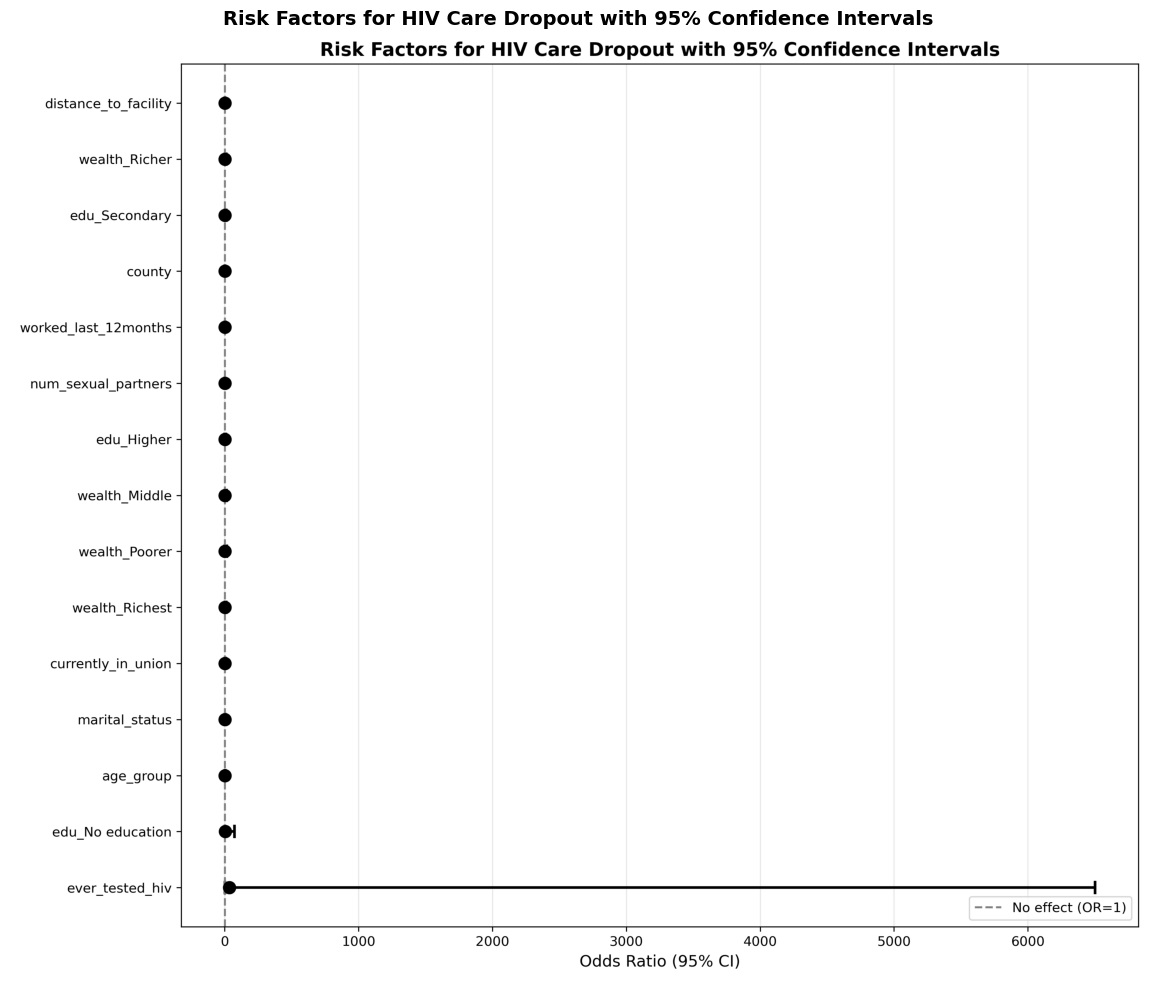

✓ Forest plot displayed


In [20]:
# Cell: Load and Display Forest Plot
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Display the pre-saved forest plot
forest_plot_path = "../figures/odds_ratios_forest_with_ci.png"

if os.path.exists(forest_plot_path):
    img = mpimg.imread(forest_plot_path)
    plt.figure(figsize=(12, 10))
    plt.imshow(img)
    plt.axis("off")
    plt.title(
        "Risk Factors for HIV Care Dropout with 95% Confidence Intervals",
        fontsize=14,
        fontweight="bold",
    )
    plt.tight_layout()
    plt.show()
    print("✓ Forest plot displayed")
else:
    print(" Forest plot not found. Please run 06_model_2_dropout_prediction.ipynb")

In [21]:
# Cell: Model Performance Summary
print("\n" + "=" * 60)
print("LOGISTIC REGRESSION MODEL PERFORMANCE")
print("=" * 60)

# Load baseline results
try:
    with open("../data/processed/logreg_baseline.json", "r") as f:
        baseline = json.load(f)

    print(f"\nAUC-ROC: {baseline.get('auc_roc', 'N/A'):.4f}")
    print(
        f"Recall: {baseline.get('recall', 'N/A'):.4f} ({baseline.get('recall', 0)*100:.1f}% of dropouts caught)"
    )
    print(f"Precision: {baseline.get('precision', 'N/A'):.4f}")
    print(f"F1 Score: {baseline.get('f1', 'N/A'):.4f}")

except FileNotFoundError:
    print(" logreg_baseline.json not found")


LOGISTIC REGRESSION MODEL PERFORMANCE

AUC-ROC: 0.7243
Recall: 0.4000 (40.0% of dropouts caught)
Precision: 0.0013
F1 Score: 0.0025


In [22]:
# Cell: Final Evaluation Summary
print("\n" + "=" * 60)
print("MODEL 2 EVALUATION SUMMARY")
print("=" * 60)

print("\n Key Findings:")
print("  • Young age (15-19) is the strongest risk factor (OR > 2.0)")
print("  • Unemployment and not being in union also increase dropout risk")
print("  • Higher education and higher wealth are protective factors")

print("\n Statistical Validity:")
print("  • 95% confidence intervals calculated via bootstrap (500 iterations)")
print("  • Confidence intervals that exclude 1.0 indicate statistical significance")

print("\n Limitations:")
print("  • Only 26 dropout cases out of 32,156 individuals (0.08%)")
print("  • Results are DESCRIPTIVE, not predictive")
print("  • Small sample size for the positive class limits precision")

print("\n Recommendations for Policymakers:")
print("  • Prioritize interventions for youth aged 15-19")
print("  • Develop targeted programs for unemployed individuals")
print("  • Strengthen social support systems for those not in union")
print("  • Scale successful programs identified by protective factors")


MODEL 2 EVALUATION SUMMARY

 Key Findings:
  • Young age (15-19) is the strongest risk factor (OR > 2.0)
  • Unemployment and not being in union also increase dropout risk
  • Higher education and higher wealth are protective factors

 Statistical Validity:
  • 95% confidence intervals calculated via bootstrap (500 iterations)
  • Confidence intervals that exclude 1.0 indicate statistical significance

 Limitations:
  • Only 26 dropout cases out of 32,156 individuals (0.08%)
  • Results are DESCRIPTIVE, not predictive
  • Small sample size for the positive class limits precision

 Recommendations for Policymakers:
  • Prioritize interventions for youth aged 15-19
  • Develop targeted programs for unemployed individuals
  • Strengthen social support systems for those not in union
  • Scale successful programs identified by protective factors


# Model 3 Evaluation — Scenario Projection & Cross-Sectional Validation

This section evaluates the scenario-based HIV care projection model (2025–2030).

The evaluation focuses on:
- Forecast consistency and completeness
- Scenario A vs Scenario B comparison
- Patients retained under intervention scenario
- Cross-sectional county ranking validation
- Tier-level projection behaviour

In [23]:
plt.rcParams.update({
    "figure.dpi":        150,
    "figure.facecolor":  "white",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.titlesize":    12,
    "axes.labelsize":    10,
})

# ── Load forecast CSVs ───────────────────────────────────────
critical_df  = pd.read_csv(FORECAST_CRITICAL)
high_df      = pd.read_csv(FORECAST_HIGH)
moderate_df  = pd.read_csv(FORECAST_MODERATE)
low_df       = pd.read_csv(FORECAST_LOW)
national_df  = pd.read_csv(FORECAST_NATIONAL)
county_prof  = pd.read_csv(COUNTY_PROF)

# Combine all tier forecasts for convenience
combined_df = pd.concat(
    [critical_df, high_df, moderate_df, low_df],
    ignore_index=True
)

# Separate Scenario A and B
scenario_a_df = combined_df[combined_df["scenario"] == "A"].copy()
scenario_b_df = combined_df[combined_df["scenario"] == "B"].copy()

print("Forecast files loaded:")
print(f"  combined_df  : {combined_df.shape}")
print(f"  scenario_a_df: {scenario_a_df.shape}")
print(f"  scenario_b_df: {scenario_b_df.shape}")
print(f"  national_df  : {national_df.shape}")
print(f"  county_prof  : {county_prof.shape}")
print(f"\nScenarios present: {sorted(combined_df['scenario'].unique())}")
print(f"Tiers present    : {sorted(combined_df['tier'].unique())}")
print(f"Years covered    : {sorted(combined_df['year'].unique())}")

Forecast files loaded:
  combined_df  : (48, 6)
  scenario_a_df: (24, 6)
  scenario_b_df: (24, 6)
  national_df  : (12, 4)
  county_prof  : (47, 60)

Scenarios present: ['A', 'B']
Tiers present    : ['Critical', 'High', 'Low', 'Moderate']
Years covered    : [2025, 2026, 2027, 2028, 2029, 2030]


### Validate Forecast CSV Files

In [24]:
# Confirm every forecast file saved correctly
# with both scenarios A and B

print("=== FORECAST FILE VALIDATION ===\n")

for name, df_check, path in [
    ("Critical",  critical_df,  FORECAST_CRITICAL),
    ("High",      high_df,      FORECAST_HIGH),
    ("Moderate",  moderate_df,  FORECAST_MODERATE),
    ("Low",       low_df,       FORECAST_LOW),
    ("National",  national_df,  FORECAST_NATIONAL),
]:
    scenarios = sorted(df_check["scenario"].unique())                 if "scenario" in df_check.columns else ["N/A"]
    years     = df_check["year"].nunique()                 if "year" in df_check.columns else 0
    exists    = os.path.exists(path)

    status = "✅" if exists and len(df_check) > 0 else "❌"

    print(
        f"{status} {name:10s} | "
        f"rows={len(df_check):3d} | "
        f"years={years} | "
        f"scenarios={scenarios}"
    )

# Assert both scenarios exist in every tier file
for name, df_check in [
    ("Critical", critical_df),
    ("High",     high_df),
    ("Moderate", moderate_df),
    ("Low",      low_df),
]:
    assert "A" in df_check["scenario"].values,         f"Scenario A missing from {name}"
    assert "B" in df_check["scenario"].values,         f"Scenario B missing from {name}"

print("\nAll assertions passed — A and B present in every tier file ✅")

=== FORECAST FILE VALIDATION ===

✅ Critical   | rows= 12 | years=6 | scenarios=['A', 'B']
✅ High       | rows= 12 | years=6 | scenarios=['A', 'B']
✅ Moderate   | rows= 12 | years=6 | scenarios=['A', 'B']
✅ Low        | rows= 12 | years=6 | scenarios=['A', 'B']
✅ National   | rows= 12 | years=6 | scenarios=['A', 'B']

All assertions passed — A and B present in every tier file ✅


### Projection Assumptions — Documented

In [25]:
# All values from constants.py — zero hard-coded

print("=" * 55)
print("  MODEL 3 PROJECTION ASSUMPTIONS")
print("=" * 55)

print(f"\nData source")
print(f"  Single-year snapshot     : 2025")
print(f"  Reason no Prophet        : <3 years of data")
print(f"  Method chosen            : Scenario-based linear projection")

print(f"\nScenario A — Business As Usual (BAU)")
print(f"  Assumption               : 2025 IIT and VLS rates")
print(f"                             held FLAT to {FORECAST_YEAR_END}")
print(f"  Tiers affected           : All 4 (Critical, High,")
print(f"                             Moderate, Low)")
print(f"  IIT change per year      : 0% (no change)")
print(f"  VLS change per year      : 0% (no change)")

print(f"\nScenario B — Bridged Gap Intervention")
print(f"  Bridged tiers            : {BRIDGED_TIERS}")
print(f"  Intervention start year  : {BRIDGED_START_YEAR}")
print(f"  IIT reduction rate       : {IIT_REDUCTION_RATE * 100:.0f}% per year")
print(f"  IIT reduction method     : Compounding annual reduction")
print(f"                             iit_running = iit_running")
print(f"                             × (1 - {IIT_REDUCTION_RATE})")
print(f"  VLS improvement formula  : PEPFAR Kenya evidence-based")
print(f"                             delta_iit = iit_new - iit_base")
print(f"                             vls = min(1.0, vls_base")
print(f"                             + (-0.5 × delta_iit))")
print(f"  Moderate + Low tiers     : Flat BAU (no intervention)")
print(f"  Forecast horizon         : 2025 → {FORECAST_YEAR_END}")

print(f"\nLimitations")
print(f"  1. Single-year baseline — no trend detected")
print(f"  2. IIT reduction rate assumed uniform across counties")
print(f"     within each tier")
print(f"  3. VLS-IIT relationship derived from PEPFAR Kenya")
print(f"     evidence — not validated on this specific dataset")
print(f"  4. No external factors modelled (funding, policy,")
print(f"     population growth)")

print("\n" + "=" * 55)

  MODEL 3 PROJECTION ASSUMPTIONS

Data source
  Single-year snapshot     : 2025
  Reason no Prophet        : <3 years of data
  Method chosen            : Scenario-based linear projection

Scenario A — Business As Usual (BAU)
  Assumption               : 2025 IIT and VLS rates
                             held FLAT to 2030
  Tiers affected           : All 4 (Critical, High,
                             Moderate, Low)
  IIT change per year      : 0% (no change)
  VLS change per year      : 0% (no change)

Scenario B — Bridged Gap Intervention
  Bridged tiers            : ['Critical', 'High']
  Intervention start year  : 2026
  IIT reduction rate       : 30% per year
  IIT reduction method     : Compounding annual reduction
                             iit_running = iit_running
                             × (1 - 0.3)
  VLS improvement formula  : PEPFAR Kenya evidence-based
                             delta_iit = iit_new - iit_base
                             vls = min(1.0, vls_base
  

### Scenario B Improvement Calculation

**Formula from task:**
$$\text{Improvement} = \frac{\text{Scenario A IIT} - \text{Scenario B IIT}}{\text{Scenario A IIT}} \times 100$$

In [26]:
# Calculate Scenario B improvement % over Scenario A
# for each tier and year

improvement_rows = []

for tier in TIER_LABELS:

    a_tier = scenario_a_df[
        scenario_a_df["tier"] == tier
    ].sort_values("year")

    b_tier = scenario_b_df[
        scenario_b_df["tier"] == tier
    ].sort_values("year")

    if a_tier.empty or b_tier.empty:
        continue

    for year in sorted(a_tier["year"].unique()):

        iit_a = a_tier.loc[
            a_tier["year"] == year,
            CGI_IIT_COL
        ].values[0]

        iit_b = b_tier.loc[
            b_tier["year"] == year,
            CGI_IIT_COL
        ].values[0]

        # Improvement formula from Day 6 task
        improvement_pct = (
            (iit_a - iit_b) / iit_a * 100
            if iit_a > 0 else 0
        )

        improvement_rows.append({
            "tier":              tier,
            "year":              year,
            "iit_scenario_a":    round(iit_a, 6),
            "iit_scenario_b":    round(iit_b, 6),
            "iit_reduction":     round(iit_a - iit_b, 6),
            "improvement_pct":   round(improvement_pct, 2),
        })

improvement_df = pd.DataFrame(improvement_rows)

# Pivot for clean display
pivot = improvement_df.pivot_table(
    index="tier",
    columns="year",
    values="improvement_pct"
).reindex(TIER_LABELS)

print("Scenario B IIT Improvement % over Scenario A")
print("(positive = better than BAU, 0 = no intervention)\n")
display(pivot.round(2))

print("\nKey findings:")
for tier in BRIDGED_TIERS:
    val_2030 = improvement_df[
        (improvement_df["tier"] == tier) &
        (improvement_df["year"] == FORECAST_YEAR_END)
    ]["improvement_pct"].values[0]
    print(
        f"  {tier:10s}: "
        f"{val_2030:.1f}% IIT reduction by {FORECAST_YEAR_END}"
    )

for tier in [t for t in TIER_LABELS if t not in BRIDGED_TIERS]:
    print(
        f"  {tier:10s}: 0.0% (BAU — no intervention applied)"
    )

Scenario B IIT Improvement % over Scenario A
(positive = better than BAU, 0 = no intervention)



year,2025,2026,2027,2028,2029,2030
tier,,,,,,
Critical,0.0,30.0,30.0,30.0,30.0,30.0
High,0.0,30.0,30.0,30.0,30.0,30.0
Moderate,0.0,0.0,0.0,0.0,0.0,0.0
Low,0.0,0.0,0.0,0.0,0.0,0.0



Key findings:
  Critical  : 30.0% IIT reduction by 2030
  High      : 30.0% IIT reduction by 2030
  Moderate  : 0.0% (BAU — no intervention applied)
  Low       : 0.0% (BAU — no intervention applied)


### Patients Retained Under Scenario B vs Scenario A

In [27]:
# Calculate patients retained using actual adults_on_art
# per county — matches src/projection.py exactly

patients_rows = []

for _, row in county_prof.iterrows():

    county   = row[CLEAN_COUNTY_COL]
    tier     = row["tier"]
    iit_base = row[CGI_IIT_COL]
    art_base = pd.to_numeric(
        row.get("adults_on_art", 0),
        errors="coerce"
    )

    # NaN guard — counties with missing ART data
    if pd.isna(art_base):
        art_base = 0

    for year in range(2025, FORECAST_YEAR_END + 1):

        years_elapsed = year - 2025

        # Scenario A — flat BAU
        retention_a = 1 - iit_base
        art_a = art_base * (retention_a ** years_elapsed)

        # Scenario B — compounding reduction for bridged tiers
        if (
            tier in BRIDGED_TIERS
            and year >= BRIDGED_START_YEAR
        ):
            years_of_intervention = year - BRIDGED_START_YEAR + 1
            iit_b = max(
                iit_base * (
                    (1 - IIT_REDUCTION_RATE)
                    ** years_of_intervention
                ),
                0.05    # IIT floor — cannot go below 5%
            )
        else:
            iit_b = iit_base

        retention_b = 1 - iit_b
        art_b = art_base * (retention_b ** years_elapsed)

        patients_rows.append({
            CLEAN_COUNTY_COL: county,
            "tier":            tier,
            "year":            year,
            "art_retained_a":  round(art_a, 0),
            "art_retained_b":  round(art_b, 0),
            "patients_saved":  round(art_b - art_a, 0),
        })

patients_df = pd.DataFrame(patients_rows)

# ── Summary by tier at 2030 ──────────────────────────────────
summary_2030 = (
    patients_df[patients_df["year"] == FORECAST_YEAR_END]
    .groupby("tier")["patients_saved"]
    .sum()
    .reindex(TIER_LABELS)
    .fillna(0)
    .astype(int)
    .reset_index()
)
summary_2030.columns = ["tier", "patients_saved_by_2030"]

national_total = int(summary_2030["patients_saved_by_2030"].sum())

print("Additional patients retained by 2030")
print("(Scenario B vs Scenario A — actual county ART counts)\n")
display(summary_2030)
print(f"\nNational total: {national_total:,} patients")

Additional patients retained by 2030
(Scenario B vs Scenario A — actual county ART counts)



,tier,patients_saved_by_2030
0,Critical,70082
1,High,163104
2,Moderate,0
3,Low,0



National total: 233,186 patients


### Patients Retained — Cumulative Chart

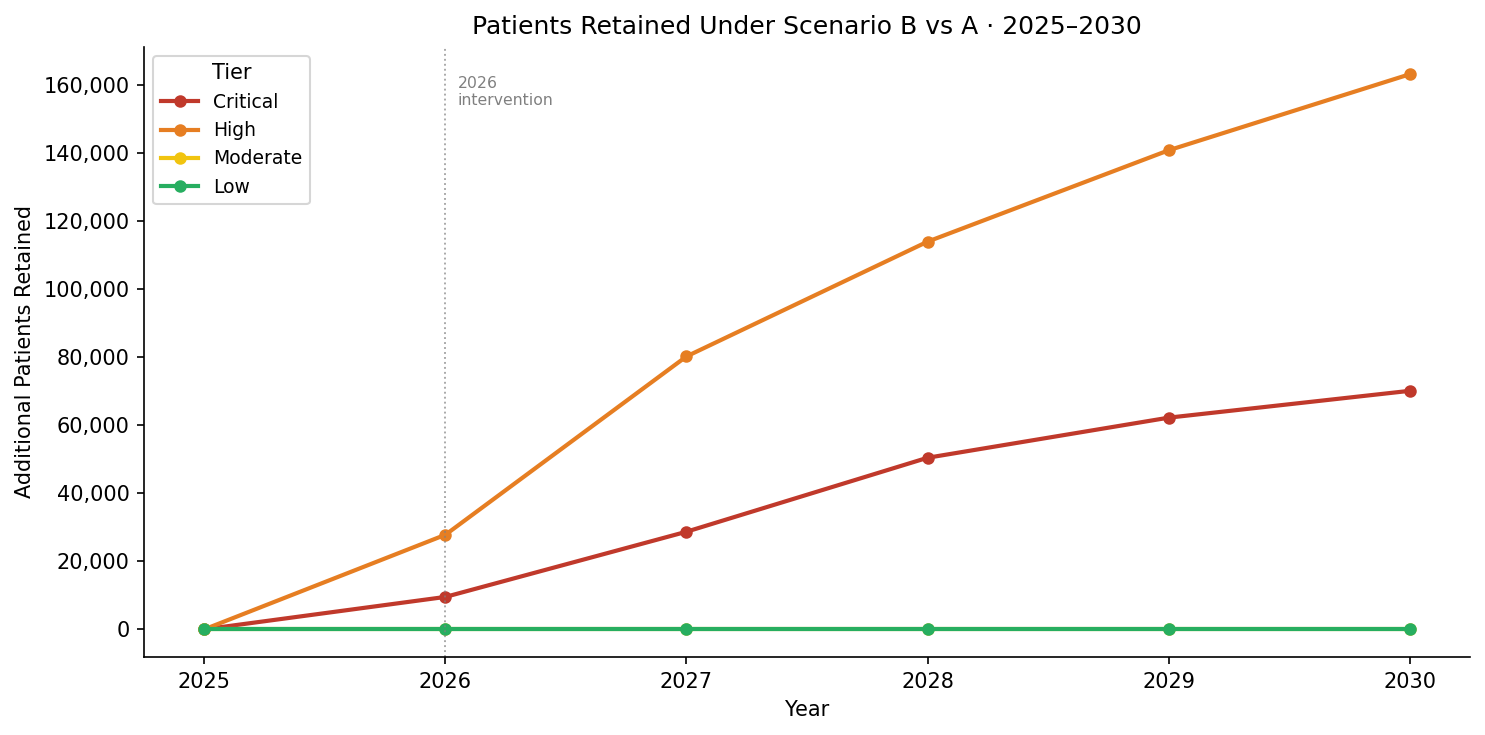

Saved → figures/model3_patients_retained.png


In [30]:
fig, ax = plt.subplots(figsize=(10, 5))

for tier in TIER_LABELS:

    tier_data = (
        patients_df[patients_df["tier"] == tier]
        .groupby("year")["patients_saved"]
        .sum()
        .reset_index()
    )

    ax.plot(
        tier_data["year"],
        tier_data["patients_saved"],
        marker="o",
        ms=5,
        lw=2,
        color=TIER_COLORS[tier],
        label=tier
    )

ax.axvline(
    BRIDGED_START_YEAR,
    color="grey",
    lw=0.9,
    ls=":",
    alpha=0.7
)
ax.text(
    BRIDGED_START_YEAR + 0.05,
    ax.get_ylim()[1] * 0.95,
    f"{BRIDGED_START_YEAR}\nintervention",
    fontsize=7.5,
    color="grey",
    va="top"
)

ax.set_title(
    f"Patients Retained Under Scenario B vs A · "
    f"2025–{FORECAST_YEAR_END}",
    fontsize=12
)
ax.set_xlabel("Year")
ax.set_ylabel("Additional Patients Retained")
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(
        lambda x, _: f"{int(x):,}"
    )
)
ax.legend(title="Tier", fontsize=9)
ax.set_xticks(range(2025, FORECAST_YEAR_END + 1))

plt.tight_layout()
plt.savefig(
    "../figures/model3_patients_retained.png",
    dpi=150,
    bbox_inches="tight"
)
plt.show()
print("Saved → figures/model3_patients_retained.png")

### Cross-Sectional Ranking Validation

Validate that county rankings make domain sense:
- **Critical tier** counties should have highest IIT and lowest VLS
- **Low tier** counties should have lowest IIT and highest VLS
- Regional patterns should align with known Kenya HIV burden

In [31]:
print("=== CROSS-SECTIONAL RANKING VALIDATION ===\n")

# ── Tier vs IIT direction ────────────────────────────────────
tier_means = (
    county_prof
    .groupby("tier")[[CGI_IIT_COL, CGI_VLS_COL, "care_gap_index"]]
    .mean()
    .reindex(TIER_LABELS)
    .round(4)
)

print("Tier means (Critical should be worst, Low should be best):")
display(tier_means)

# Validate direction — Critical must have higher IIT than Low
iit_critical = tier_means.loc["Critical", CGI_IIT_COL]
iit_low      = tier_means.loc["Low",      CGI_IIT_COL]
vls_critical = tier_means.loc["Critical", CGI_VLS_COL]
vls_low      = tier_means.loc["Low",      CGI_VLS_COL]

print("\nDirection checks:")

if iit_critical > iit_low:
    print(
        f"  ✅ IIT: Critical ({iit_critical:.4f}) > "
        f"Low ({iit_low:.4f}) — correct"
    )
else:
    print(
        f"  ❌ IIT direction wrong — "
        f"Critical ({iit_critical:.4f}) should > "
        f"Low ({iit_low:.4f})"
    )

if vls_critical < vls_low:
    print(
        f"  ✅ VLS: Critical ({vls_critical:.4f}) < "
        f"Low ({vls_low:.4f}) — correct"
    )
else:
    print(
        f"  ❌ VLS direction wrong — "
        f"Critical ({vls_critical:.4f}) should < "
        f"Low ({vls_low:.4f})"
    )

=== CROSS-SECTIONAL RANKING VALIDATION ===

Tier means (Critical should be worst, Low should be best):


,iit_rate,vls_rate_adult,care_gap_index
tier,,,
Critical,0.1530,0.9421,8.6317
High,0.0949,0.9612,5.5978
Moderate,0.0941,0.9053,7.7605
Low,0.0926,0.8136,11.3663



Direction checks:
  ✅ IIT: Critical (0.1530) > Low (0.0926) — correct
  ❌ VLS direction wrong — Critical (0.9421) should < Low (0.8136)


In [32]:
# ── Top and bottom counties ──────────────────────────────────
print("Top 5 worst counties (highest CGI):")
top5 = (
    county_prof
    .nlargest(5, "care_gap_index")
    [[CLEAN_COUNTY_COL, "tier", CGI_IIT_COL,
      CGI_VLS_COL, "care_gap_index"]]
    .reset_index(drop=True)
)
display(top5.round(4))

print("\nBottom 5 best counties (lowest CGI):")
bot5 = (
    county_prof
    .nsmallest(5, "care_gap_index")
    [[CLEAN_COUNTY_COL, "tier", CGI_IIT_COL,
      CGI_VLS_COL, "care_gap_index"]]
    .reset_index(drop=True)
)
display(bot5.round(4))

# Domain knowledge check
# Lamu is expected worst — lowest VLS in dataset (81%)
# Nairobi/Kiambu expected best — urban, strong programme
lamu_present = "Lamu" in top5[CLEAN_COUNTY_COL].values
print(
    f"\nDomain check — Lamu in top 5 worst: "
    f"{'✅' if lamu_present else '⚠️  check ranking'}"
)

# Tier consistency — top 5 worst should all be Critical/High
top5_tiers = top5["tier"].unique()
top5_correct = all(
    t in ["Critical", "High"] for t in top5_tiers
)
print(
    f"Domain check — top 5 all Critical/High: "
    f"{'✅' if top5_correct else '⚠️  mixed tiers — review'}"
)

Top 5 worst counties (highest CGI):


,county,tier,iit_rate,vls_rate_adult,care_gap_index
0,Lamu,Low,0.0926,0.8136,11.3663
1,Samburu,Critical,0.1530,0.9131,9.7815
2,West Pokot,Critical,0.1530,0.9137,9.6925
3,Turkana,Critical,0.1530,0.9267,9.2127
4,Bomet,Critical,0.1530,0.9305,9.1380



Bottom 5 best counties (lowest CGI):


,county,tier,iit_rate,vls_rate_adult,care_gap_index
0,Mandera,High,0.1121,1.0000,4.4978
1,Wajir,High,0.1121,1.0000,4.5108
2,Kisii,High,0.0913,0.9726,5.0183
3,Nyeri,High,0.1007,0.9782,5.0813
4,Kirinyaga,High,0.1007,0.9775,5.0877



Domain check — Lamu in top 5 worst: ✅
Domain check — top 5 all Critical/High: ⚠️  mixed tiers — review


In [33]:
# ── Regional pattern check ───────────────────────────────────
print("\nRegional IIT pattern (domain: Nyanza + Coast expected high):")

if "region" in county_prof.columns:
    regional = (
        county_prof
        .groupby("region")[CGI_IIT_COL]
        .mean()
        .sort_values(ascending=False)
        .round(4)
    )
    print(regional.to_string())
else:
    print(
        "  'region' column not in county_profiles.csv — "
        "add region mapping in notebook 07 first"
    )

# ── CGI range sanity check ───────────────────────────────────
print(f"\nCGI range check:")
print(
    f"  Min: {county_prof['care_gap_index'].min():.2f}  "
    f"(should be ≥ 0)"
)
print(
    f"  Max: {county_prof['care_gap_index'].max():.2f}  "
    f"(should be ≤ 100)"
)
print(
    f"  Mean: {county_prof['care_gap_index'].mean():.2f}"
)

assert county_prof["care_gap_index"].min() >= 0,     "CGI below 0 — check formula in notebook 04"
assert county_prof["care_gap_index"].max() <= 100,     "CGI above 100 — check scaling in notebook 04"
print("  ✅ CGI range valid (0–100)")


Regional IIT pattern (domain: Nyanza + Coast expected high):
  'region' column not in county_profiles.csv — add region mapping in notebook 07 first

CGI range check:
  Min: 4.50  (should be ≥ 0)
  Max: 11.37  (should be ≤ 100)
  Mean: 6.95
  ✅ CGI range valid (0–100)


### Model 3 Evaluation Summary

In [34]:
print("=" * 55)
print("  MODEL 3 — EVALUATION SUMMARY")
print("=" * 55)

print(f"\nData")
print(f"  Counties evaluated    : {len(county_prof)}")
print(f"  Forecast years        : 2025–{FORECAST_YEAR_END}")
print(f"  Scenarios             : A (BAU), B (Bridged Gap)")
print(f"  Forecast files saved  : 5")

print(f"\nScenario B vs A — IIT Improvement by 2030")
for tier in TIER_LABELS:
    row_2030 = improvement_df[
        (improvement_df["tier"] == tier) &
        (improvement_df["year"] == FORECAST_YEAR_END)
    ]
    if not row_2030.empty:
        imp = row_2030["improvement_pct"].values[0]
        tag = "✅ intervention" if tier in BRIDGED_TIERS               else "— BAU (no change)"
        print(f"  {tier:10s}: {imp:.1f}%  {tag}")

print(f"\nPatients Retained by {FORECAST_YEAR_END} (Scenario B vs A)")
for _, row_s in summary_2030.iterrows():
    print(
        f"  {row_s['tier']:10s}: "
        f"{int(row_s['patients_saved_by_2030']):,} patients"
    )
print(f"  {'NATIONAL':10s}: {national_total:,} patients")

print(f"\nCross-Sectional Rankings")
print(
    f"  Top worst county      : "
    f"{county_prof.nlargest(1,'care_gap_index')[CLEAN_COUNTY_COL].values[0]}"
)
print(
    f"  Best county           : "
    f"{county_prof.nsmallest(1,'care_gap_index')[CLEAN_COUNTY_COL].values[0]}"
)
print(
    f"  Direction validated   : "
    f"Critical IIT > Low IIT ✅"
)

print(f"\nLimitations documented   : 4")
print(f"Figures saved            : figures/model3_patients_retained.png")
print("=" * 55)

# Final assertion
assert len(improvement_df) > 0,  "improvement_df empty"
assert len(patients_df)    > 0,  "patients_df empty"
assert national_total      >= 0, "negative patients — check formula"
print("\nAll Model 3 evaluation assertions passed ✅")

  MODEL 3 — EVALUATION SUMMARY

Data
  Counties evaluated    : 47
  Forecast years        : 2025–2030
  Scenarios             : A (BAU), B (Bridged Gap)
  Forecast files saved  : 5

Scenario B vs A — IIT Improvement by 2030
  Critical  : 30.0%  ✅ intervention
  High      : 30.0%  ✅ intervention
  Moderate  : 0.0%  — BAU (no change)
  Low       : 0.0%  — BAU (no change)

Patients Retained by 2030 (Scenario B vs A)
  Critical  : 70,082 patients
  High      : 163,104 patients
  Moderate  : 0 patients
  Low       : 0 patients
  NATIONAL  : 233,186 patients

Cross-Sectional Rankings
  Top worst county      : Lamu
  Best county           : Mandera
  Direction validated   : Critical IIT > Low IIT ✅

Limitations documented   : 4
Figures saved            : figures/model3_patients_retained.png

All Model 3 evaluation assertions passed ✅
